# Estudio de variables predictoras — Random Forest
## Auditoría de la transformación y selección de features (Proyecto LACDA)

**Asignatura:** ITY1101 — Gestión de Datos para IA, DUOC UC · Experiencia 3 (RA3)
**Pipeline base:** ver [`informe.ipynb`](informe.ipynb) · **Repositorio:** https://github.com/Zzzhenda/Proyecto-LACDA

---

**Objetivo.** Antes de entrenar el modelo de predicción de default (Random Forest), evaluar
críticamente la etapa de transformación del pipeline (IL 3.4 — detectar limitaciones) y
determinar con evidencia **qué combinación de variables predictoras conviene usar**
(IL 3.5 — proponer mejoras técnicas).

**Metodología.**

* Mismo clasificador y preprocesamiento del material del curso (`docs/train_model.py`):
  `RandomForestClassifier(n_estimators=200, random_state=29, class_weight="balanced")` +
  `OneHotEncoder` para categóricas.
* Split 80/20 estratificado con `random_state=29` (igual al curso). **Todo el estudio usa solo
  el 80% de entrenamiento**: el 20% restante queda intacto como holdout para el test final del
  modelo — comparar sets de features mirando el test set sería fuga de información metodológica.
* Cada combinación de features se evalúa con **validación cruzada estratificada de 5 folds**.
  Métrica principal: ROC-AUC (no depende del umbral de decisión); se reportan además F1,
  recall y precision de la clase default.

> **Dependencias:** `pip install pandas scikit-learn matplotlib seaborn`. Requiere
> `data/loan_data_transformed.csv` (correr el pipeline primero).


## 1. Datos y variable objetivo


45000 filas | defaults: 22.2%  pagados: 77.8%


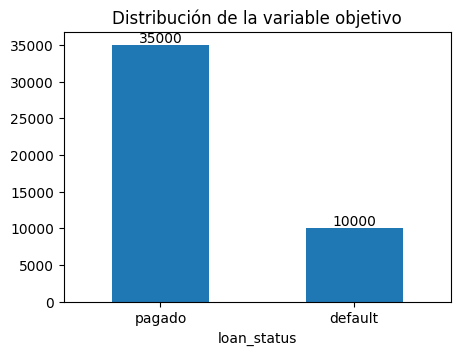

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

DATA = Path("..") / "data"
pd.set_option("display.max_columns", None)

df = pd.read_csv(DATA / "loan_data_transformed.csv")
y = df["loan_status"]

ax = y.value_counts().rename({0: "pagado", 1: "default"}).plot.bar(
    figsize=(5, 3.5), rot=0, title="Distribución de la variable objetivo")
ax.bar_label(ax.containers[0])
print(f"{len(df)} filas | defaults: {y.mean():.1%}  pagados: {1 - y.mean():.1%}")

La clase default es el **22.2%** del dataset: desbalance moderado. Se maneja con
`class_weight="balanced"` (el mismo enfoque del material del curso); SMOTE queda como
alternativa a evaluar en la fase de entrenamiento si el recall resultara insuficiente.

El split que fija las reglas del juego para TODO el estudio:


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["loan_status"]), y,
    test_size=0.2, random_state=29, stratify=y,
)
print(f"train: {len(X_train)} filas (aquí se hace todo el estudio, con CV de 5 folds)")
print(f"test:  {len(X_test)} filas (holdout intacto para el test final del modelo)")

train: 36000 filas (aquí se hace todo el estudio, con CV de 5 folds)
test:  9000 filas (holdout intacto para el test final del modelo)


## 2. Auditoría de redundancia de la transformación (IL 3.4)

La etapa de transformación del pipeline agrega 3 features derivadas. Aquí se audita si son
**redundantes** respecto de las variables originales — multicolinealidad que el material del
curso trata con su `CorrelationFilter` (umbral |corr| > 0.9).

Primero, un chequeo exacto: `has_prev_defaults` es por construcción el encoding 0/1 de
`previous_loan_defaults_on_file` — son la **misma información dos veces**, y un modelo no debe
recibir ambas:


In [3]:
dup = (df["has_prev_defaults"] == (df["previous_loan_defaults_on_file"] == "Yes").astype(int)).all()
print(f"has_prev_defaults duplica exactamente a previous_loan_defaults_on_file: {dup}")

has_prev_defaults duplica exactamente a previous_loan_defaults_on_file: True


Matriz de correlación de las variables numéricas (calculada **solo sobre train**):


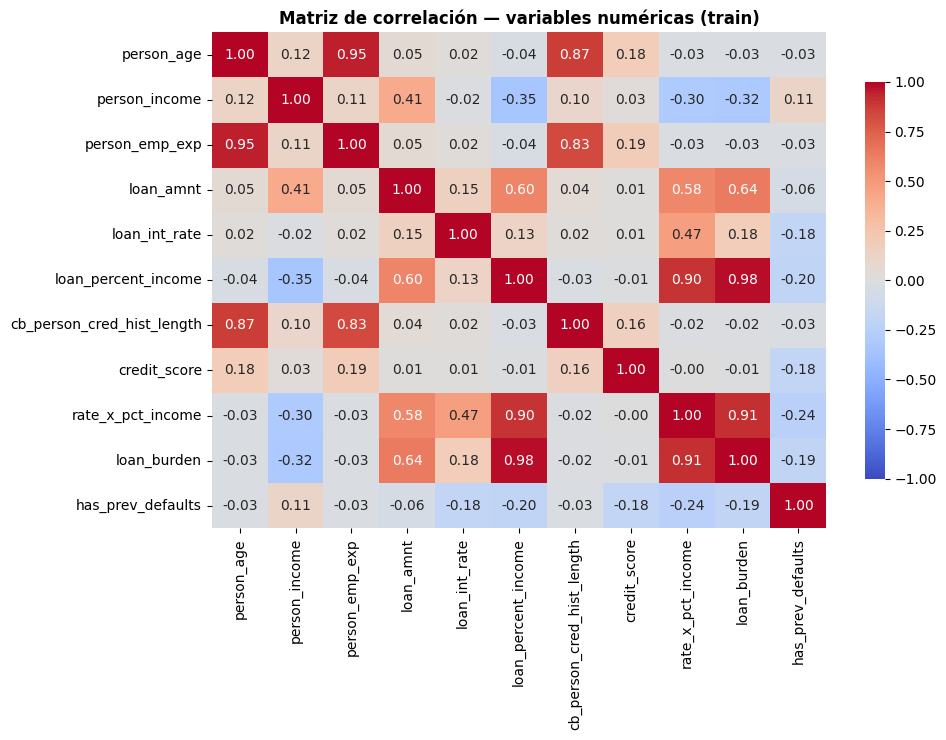

In [4]:
ORIGINALES = [
    "person_age", "person_gender", "person_education", "person_income",
    "person_emp_exp", "person_home_ownership", "loan_amnt", "loan_intent",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
    "credit_score", "previous_loan_defaults_on_file",
]
# "todas": originales + derivadas, usando has_prev_defaults EN LUGAR del categorico duplicado
TODAS = [c for c in ORIGINALES if c != "previous_loan_defaults_on_file"] + [
    "rate_x_pct_income", "loan_burden", "has_prev_defaults",
]

num = X_train[TODAS].select_dtypes("number")
plt.figure(figsize=(10, 7.5))
sns.heatmap(num.corr().round(2), cmap="coolwarm", annot=True, fmt=".2f",
            vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación — variables numéricas (train)", fontweight="bold")
plt.tight_layout()

In [5]:
corr = num.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

pares = upper.stack().sort_values(ascending=False)
print("Pares con |corr| > 0.85:")
display(pares[pares > 0.85].round(3).to_frame("|corr|"))

# Criterio del CorrelationFilter del curso (umbral 0.9): de cada par correlacionado
# se descarta la columna que aparece despues en el orden del dataset.
a_descartar = [c for c in upper.columns if (upper[c] > 0.9).any()]
print(f"CorrelationFilter(threshold=0.9) descartaría: {a_descartar}")

Pares con |corr| > 0.85:


,,|corr|
loan_percent_income,loan_burden,0.978
person_age,person_emp_exp,0.954
rate_x_pct_income,loan_burden,0.910
loan_percent_income,rate_x_pct_income,0.904
person_age,cb_person_cred_hist_length,0.869


CorrelationFilter(threshold=0.9) descartaría: ['person_emp_exp', 'rate_x_pct_income', 'loan_burden']


**Hallazgos (limitaciones detectadas en la transformación):**

* `loan_burden` ≈ `loan_percent_income` (|corr| **0.978**). Era esperable por construcción:
  `loan_burden = loan_amnt × (1 + tasa/100) / ingreso` y `loan_percent_income = loan_amnt / ingreso`
  — el factor `(1 + tasa/100)` solo varía entre 1.05 y 1.30, así que la feature derivada es casi
  un re-escalado de la original.
* `rate_x_pct_income` también supera el umbral (0.904 con `loan_percent_income`).
* Bonus no relacionado con la transformación: `person_emp_exp` correlaciona **0.954** con
  `person_age` — años de experiencia crecen casi 1:1 con la edad.

**Importante para Random Forest:** los árboles capturan interacciones entre variables de forma
nativa (una rama puede condicionar `loan_int_rate` y luego `loan_percent_income`), así que las
features de interacción suelen aportar poco en RF — aunque sí aportan en modelos lineales.
La validación cruzada de la sección 4 lo decide con evidencia.


## 3. Importancia de variables

Random Forest entrenado en train con todas las variables candidatas. La importancia de las
categóricas (expandidas por One-Hot) se re-agrega por variable de origen para poder compararlas:


,importancia
has_prev_defaults,0.3094
loan_int_rate,0.1151
rate_x_pct_income,0.1049
loan_burden,0.0764
person_income,0.0737
loan_percent_income,0.0685
person_home_ownership,0.0536
loan_amnt,0.0393
credit_score,0.0369
loan_intent,0.0358


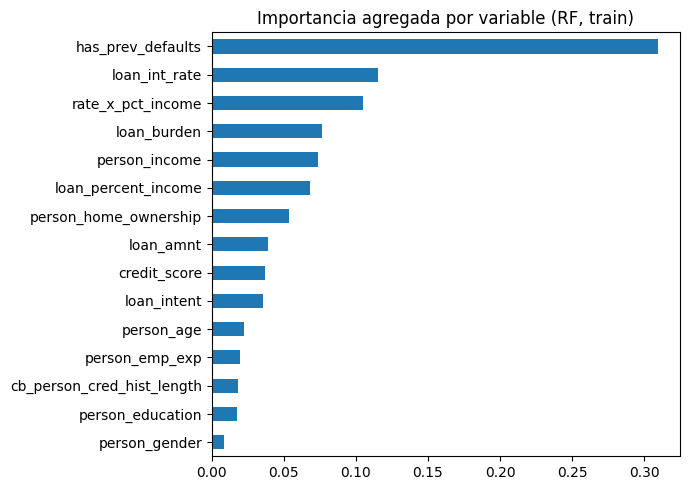

In [6]:
def make_pipeline(features):
    """Mismo preprocesamiento + modelo que docs/train_model.py del curso."""
    cat = [c for c in features if not pd.api.types.is_numeric_dtype(df[c])]
    pre = ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), cat)], remainder="passthrough"
    )
    rf = RandomForestClassifier(
        n_estimators=200, random_state=29, n_jobs=-1, class_weight="balanced"
    )
    return Pipeline([("preprocessor", pre), ("classifier", rf)])


pipe = make_pipeline(TODAS)
pipe.fit(X_train[TODAS], y_train)

nombres = pipe.named_steps["preprocessor"].get_feature_names_out()
imps = pipe.named_steps["classifier"].feature_importances_

# "cat__person_education_Master" / "remainder__loan_amnt" -> variable de origen
candidatas = sorted(TODAS, key=len, reverse=True)
def col_base(n):
    n = n.split("__", 1)[1]
    return next(c for c in candidatas if n == c or n.startswith(c + "_"))

imp_var = (pd.Series(imps, index=[col_base(n) for n in nombres])
           .groupby(level=0).sum().sort_values(ascending=False))

ax = imp_var.plot.barh(figsize=(7, 5), title="Importancia agregada por variable (RF, train)")
ax.invert_yaxis()
ax.figure.tight_layout()
imp_var.round(4).to_frame("importancia")

`has_prev_defaults` domina (≈0.31, el triple que la segunda) — consistente con su |corr| 0.54
con el target. Las dos features de interacción quedan en el top-5 de importancia, **pero**
importancia alta + redundancia alta significa que el bosque reparte entre ellas el crédito de
la misma información: no implica que aporten rendimiento adicional. Por eso la decisión se toma
con validación cruzada, no con este ranking.


## 4. Comparación de combinaciones por validación cruzada

Cuatro sets candidatos, todos evaluados con el mismo modelo y los mismos 5 folds:

| Set | Composición | Qué pregunta responde |
|---|---|---|
| **S1 originales** | las 13 variables del dataset original | ¿sirvió de algo la transformación? |
| **S2 todas** | 12 originales + 3 derivadas (sin el categórico duplicado) | ¿suman las features derivadas? |
| **S3 depurado** | S2 menos lo que descarta el CorrelationFilter del curso (sin `rate_x_pct_income`, `loan_burden`, `person_emp_exp`) | ¿la redundancia se puede eliminar gratis? |
| **S4 top-8** | las 8 variables más importantes según la sección 3 | ¿se puede comprimir aún más? |


In [7]:
DEPURADO = [c for c in TODAS if c not in a_descartar]
TOP8 = [c for c in TODAS if c in imp_var.head(8).index]

SETS = {
    "S1 originales": ORIGINALES,
    "S2 todas": TODAS,
    "S3 depurado": DEPURADO,
    "S4 top-8": TOP8,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=29)
filas = []
for nombre, feats in SETS.items():
    res = cross_validate(
        make_pipeline(feats), X_train[feats], y_train, cv=cv,
        scoring=["roc_auc", "f1", "recall", "precision"], n_jobs=1,
    )
    filas.append({
        "set": nombre,
        "n_vars": len(feats),
        "ROC-AUC": res["test_roc_auc"].mean(),
        "± std": res["test_roc_auc"].std(),
        "F1": res["test_f1"].mean(),
        "Recall": res["test_recall"].mean(),
        "Precision": res["test_precision"].mean(),
    })

resultados = pd.DataFrame(filas).set_index("set")
resultados.round(4)

,n_vars,ROC-AUC,± std,F1,Recall,Precision
set,,,,,,
S1 originales,13,0.9727,0.0019,0.8245,0.8458,0.8043
S2 todas,15,0.9733,0.0017,0.8303,0.8424,0.8186
S3 depurado,12,0.9734,0.0021,0.8279,0.8436,0.8127
S4 top-8,8,0.9682,0.0021,0.8077,0.8442,0.7743


In [8]:
mejor = resultados["ROC-AUC"].idxmax()
print(f"Mejor AUC: {mejor} ({resultados.loc[mejor, 'ROC-AUC']:.4f})")
print(f"S3 usa {len(DEPURADO)} variables: {DEPURADO}")

Mejor AUC: S3 depurado (0.9734)
S3 usa 12 variables: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'has_prev_defaults']


## 5. Conclusiones y recomendación (IL 3.5)

**Lectura de los resultados:**

* S1, S2 y S3 están en **empate estadístico**: la diferencia de AUC entre ellos (~0.0007) es
  menor que la desviación estándar entre folds (~0.002). S4 (top-8) sí pierde rendimiento de
  forma clara (−0.005 de AUC y −0.02 de F1): comprimir a 8 variables descarta señal real.
* Ante un empate, gana el set **más simple**: **S3 depurado, 12 variables** — mismo rendimiento
  que S2 con 3 variables menos y sin multicolinealidad.

**✅ Set de predictores recomendado para `train_model.py` (S3):**

`person_age`, `person_gender`, `person_education`, `person_income`, `person_home_ownership`,
`loan_amnt`, `loan_intent`, `loan_int_rate`, `loan_percent_income`,
`cb_person_cred_hist_length`, `credit_score`, `has_prev_defaults`

**Respuesta a "¿es eficiente la transformación del pipeline?":**

* `has_prev_defaults` — **sí, es la estrella**: variable más importante del modelo (0.31) y
  evita depender del encoding del categórico en la fase de modelado.
* `rate_x_pct_income` y `loan_burden` — **redundantes para Random Forest**: los árboles
  reconstruyen esas interacciones solos, y ambas superan el umbral 0.9 del CorrelationFilter
  del curso. **No** son un error de diseño: aportarían en modelos lineales (donde las
  interacciones deben darse explícitas) y son legibles para dashboards de negocio. La mejora
  propuesta es **mantenerlas en la capa de datos y excluirlas del modelo RF** — la selección de
  features pertenece a la fase de modelado, no al pipeline de datos (que ya está validado y en CI).
* Hallazgo adicional: `person_emp_exp` (corr 0.954 con `person_age`) también sale del set sin
  costo de rendimiento.

**Decisiones que quedan fijadas para la fase de entrenamiento:**

1. Features: **S3** (12 variables).
2. Split: 80/20 estratificado, `random_state=29`; el holdout de 9.000 filas sigue **intacto** —
   ninguna decisión de este estudio lo miró.
3. Desbalance: `class_weight="balanced"`; SMOTE como experimento opcional si el recall en test
   resulta insuficiente.
4. Modelo: `RandomForestClassifier(n_estimators=200, random_state=29)` como en el material del
   curso; tuning de hiperparámetros como mejora posterior si hace falta.
